In [28]:
# --- 1.  pull the symmetry straight from the module -----------------
from orix.quaternion.symmetry import O, Oh   # cubic, w/ or w/o inversion

sym = Oh        # full m-3m symmetry for γ-Ni (Inconel 718 matrix)

# --- 2. or, derive it from the space-group number -------------------
from orix.quaternion.symmetry import get_point_group

sym     = get_point_group(225)          # → Oh  (m-3m)
sym_fcc = get_point_group(225, proper=True)   # → O   (432)

In [29]:
import orix, importlib, pathlib, sys
print("orix version:", orix.__version__)
print("loaded from :", pathlib.Path(orix.__file__))


orix version: 0.13.3
loaded from : /home/umang/miniconda3/envs/material/lib/python3.10/site-packages/orix/__init__.py


In [30]:
import inspect, orix
from orix.quaternion import Orientation
print(inspect.getfile(Orientation))


/home/umang/miniconda3/envs/material/lib/python3.10/site-packages/orix/quaternion/orientation.py


In [31]:
import numpy as np
from orix.quaternion import Orientation
from orix.quaternion.symmetry import get_point_group
from orix.vector import Vector3d
from orix.plot import IPFColorKeyTSL           # still available for legacy colour keys

sym_fcc = get_point_group(225, proper=True)    # cubic 432

def quaternion_to_ipf(quats, axis="Z"):
    ori = Orientation(np.asarray(quats), symmetry=sym_fcc)

    key = IPFColorKeyTSL(
        sym_fcc,
        direction=getattr(Vector3d, f"{axis.lower()}vector")()
    )
    return key.orientation2color(ori)          # (N, 3) in 0–1 RGB


In [32]:
Qs = [
    [1, 0, 0, 0],
    [0.92388, 0, 0.38268, 0],
    [0.70711, 0.70711, 0, 0],
]
print(quaternion_to_ipf(Qs, axis="Z"))

[[1.00000000e+00 1.11022302e-16 0.00000000e+00]
 [5.27049472e-03 1.00000000e+00 0.00000000e+00]
 [1.00000000e+00 1.11022302e-16 0.00000000e+00]]


[[1.00000000e+00 1.11022302e-16 0.00000000e+00]
 [4.91822244e-01 1.00000000e+00 2.84206240e-01]
 [1.40418575e-01 1.33115863e-01 1.00000000e+00]]


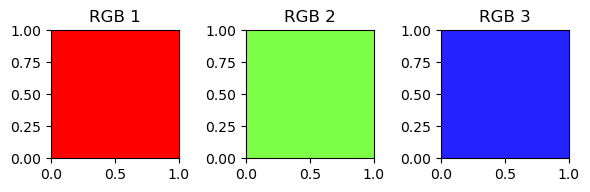

In [33]:
# get RGB colours for Qs
import os

#Example with three orientations
Qs = [
    [1, 0, 0, 0],      # identity
    [0.94177115, 0.07504171, -0.29972738, -0.13266438 ],     # supposed to be BLUE orientation
    [ 0.86994576, 0.3598948, 0.32445887, 0.09163266,]   # supposed to be GREEN orientation
]
rgbs = quaternion_to_ipf(Qs, axis="Z")  # ready for scatter
print(rgbs)  # prints RGB values in 0–1 range

# display RGB colours
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, len(rgbs), figsize=(len(rgbs)*2, 2))
for i, rgb in enumerate(rgbs):
    axes[i].add_patch(mpatches.Rectangle((0, 0), 1, 1, color=rgb))
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)
    axes[i].set_title(f'RGB {i+1}')
    axes[i].set_aspect('equal')
plt.tight_layout()
plt.show()

### Blue fz reduced

In [35]:
# [ 0.07495372 -0.29969922 -0.13278782  0.9417691 ]
# [ 0.08016635 -0.29843408 -0.13231218  0.9418092 ]
# [0.0800578  -0.29855603 -0.13238204  0.9417696 ]
# [ 0.07942707 -0.29865852 -0.13272333  0.9417425 ]
# [ 0.08037322 -0.2983399  -0.13265304  0.9417735 ]
# [ 0.07404468 -0.30848798 -0.12386742  0.9402176 ]
# [ 0.07424826 -0.30844918 -0.12406623  0.94018763]
# [ 0.07475632 -0.3083099  -0.12427451  0.9401658 ]
# [ 0.07459653 -0.3085948  -0.12400715  0.9401206 ]
# [ 0.0801684  -0.29864278 -0.13185425  0.94180703]

[[ 0.9417691   0.07495372 -0.29969922 -0.13278782]
 [ 0.9418092   0.08016635 -0.29843408 -0.13231218]
 [ 0.9417696   0.0800578  -0.29855603 -0.13238204]
 [ 0.9417425   0.07942707 -0.29865852 -0.13272333]
 [ 0.9417735   0.08037322 -0.2983399  -0.13265304]
 [ 0.9402176   0.07404468 -0.30848798 -0.12386742]
 [ 0.94018763  0.07424826 -0.30844918 -0.12406623]
 [ 0.9401658   0.07475632 -0.3083099  -0.12427451]
 [ 0.9401206   0.07459653 -0.3085948  -0.12400715]
 [ 0.94180703  0.0801684  -0.29864278 -0.13185425]]
[[0.49175153 1.         0.28314001]
 [0.50756763 1.         0.33111856]
 [0.50659651 1.         0.32980601]
 [0.50469513 1.         0.32327108]
 [0.50811026 1.         0.33206425]
 [0.44616399 1.         0.28841431]
 [0.44653916 1.         0.28963069]
 [0.44802745 1.         0.29356627]
 [0.44635048 1.         0.29257795]
 [0.50676323 1.         0.33212707]]


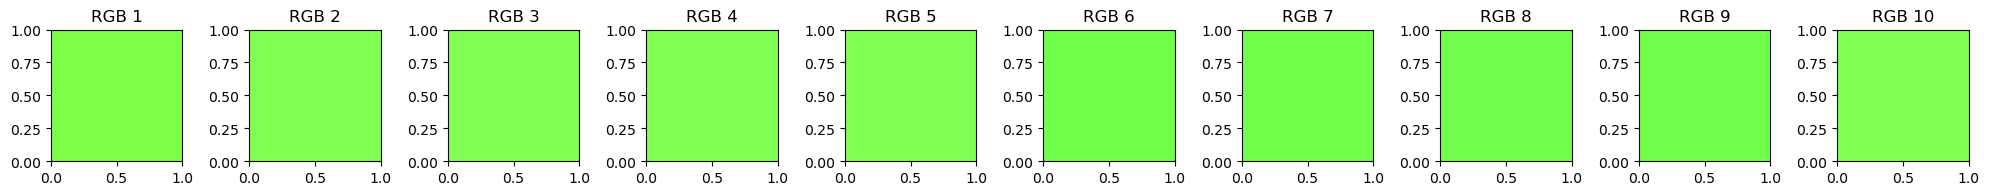

In [51]:
# get RGB colours for Qs
import os


#Example with three orientations
Qs = [[ 0.07495372, -0.29969922, -0.13278782,  0.9417691 ],
[ 0.08016635, -0.29843408, -0.13231218,  0.9418092 ],
[0.0800578,  -0.29855603, -0.13238204,  0.9417696 ],
[ 0.07942707, -0.29865852, -0.13272333,  0.9417425 ],
[ 0.08037322, -0.2983399,  -0.13265304,  0.9417735 ],
[ 0.07404468, -0.30848798, -0.12386742,  0.9402176 ],
[ 0.07424826, -0.30844918, -0.12406623,  0.94018763],
[ 0.07475632, -0.3083099,  -0.12427451,  0.9401658 ],
[ 0.07459653, -0.3085948,  -0.12400715,  0.9401206 ],
[ 0.0801684,  -0.29864278, -0.13185425,  0.94180703]]

q = np.asarray(Qs)
# bring last quaternion dimension to the front (Scalar first)
# roll the last axis to the front (scalar first)
q = np.roll(q, shift=1, axis=-1)
print(q)  # prints quaternions in [s, x, y, z] order
rgbs = quaternion_to_ipf(q, axis="Z")  # ready for scatter
print(rgbs)  # prints RGB values in 0–1 range


# display RGB colours
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, len(rgbs), figsize=(len(rgbs)*2, 2))
for i, rgb in enumerate(rgbs):
    axes[i].add_patch(mpatches.Rectangle((0, 0), 1, 1, color=rgb))
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)
    axes[i].set_title(f'RGB {i+1}')
    axes[i].set_aspect('equal')
plt.tight_layout()
plt.show()

### Blue fz not reduced.

In [ ]:
# Median quaternions shape (not fz_reduced): (10, 4)
# Median Quaternion for blue Pixel 1 at (0, 0): [ 0.7193431  -0.3054508   0.1185355   0.61253136]
# Median Quaternion for blue Pixel 2 at (0, 1): [ 0.7222587  -0.30481237  0.11776629  0.60956013]
# Median Quaternion for blue Pixel 3 at (0, 2): [ 0.26752776 -0.15459934 -0.75975347  0.57210416]
# Median Quaternion for blue Pixel 4 at (0, 3): [ 0.2675557  -0.15492967 -0.7596587   0.5721268 ]
# Median Quaternion for blue Pixel 5 at (0, 4): [ 0.72269666 -0.30477482  0.11727791  0.60915303]
# Median Quaternion for blue Pixel 6 at (0, 5): [ 0.7172371  -0.30576512  0.13053595  0.61240435]
# Median Quaternion for blue Pixel 7 at (0, 6): [ 0.27039996 -0.16590156 -0.7525132   0.57713455]
# Median Quaternion for blue Pixel 8 at (0, 7): [ 0.27038926 -0.16615348 -0.7526237   0.5769241 ]
# Median Quaternion for blue Pixel 9 at (0, 8): [ 0.7175133  -0.30589578  0.13052318  0.6120179 ]
# Median Quaternion for blue Pixel 10 at (0, 9): [ 0.7225263  -0.30472153  0.11754471  0.60933053]

In [52]:
# get RGB colours for Qs
import os
#Example with three orientations
Qs = [[ 0.7193431,  -0.3054508,   0.1185355,   0.61253136],
[ 0.7222587,  -0.30481237,  0.11776629,  0.60956013],
[ 0.26752776, -0.15459934, -0.75975347,  0.57210416],
[ 0.2675557,  -0.15492967, -0.7596587,   0.5721268 ],
[ 0.72269666, -0.30477482,  0.11727791,  0.60915303],
[ 0.7172371,  -0.30576512,  0.13053595,  0.61240435],
[ 0.27039996, -0.16590156, -0.7525132,   0.57713455],
[ 0.27038926, -0.16615348, -0.7526237,   0.5769241 ],
[ 0.7175133,  -0.30589578,  0.13052318,  0.6120179 ],
[ 0.7225263,  -0.30472153,  0.11754471,  0.60933053]]

q = np.asarray(Qs)
# bring last quaternion dimension to the front (Scalar first)
# roll the last axis to the front (scalar first)
q = np.roll(q, shift=1, axis=-1)

print(q)  # prints quaternions in [s, x, y, z] order
rgbs = quaternion_to_ipf(q, axis="Z")  # ready for scatter
print(rgbs)  # prints RGB values in 0–1 range


[[ 0.61253136  0.7193431  -0.3054508   0.1185355 ]
 [ 0.60956013  0.7222587  -0.30481237  0.11776629]
 [ 0.57210416  0.26752776 -0.15459934 -0.75975347]
 [ 0.5721268   0.2675557  -0.15492967 -0.7596587 ]
 [ 0.60915303  0.72269666 -0.30477482  0.11727791]
 [ 0.61240435  0.7172371  -0.30576512  0.13053595]
 [ 0.57713455  0.27039996 -0.16590156 -0.7525132 ]
 [ 0.5769241   0.27038926 -0.16615348 -0.7526237 ]
 [ 0.6120179   0.7175133  -0.30589578  0.13052318]
 [ 0.60933053  0.7225263  -0.30472153  0.11754471]]
[[1.         0.06674656 0.47498775]
 [1.         0.1033657  0.48690045]
 [0.50639464 1.         0.32727437]
 [0.50462114 1.         0.3252969 ]
 [1.         0.10677989 0.48952796]
 [1.         0.10667866 0.44794146]
 [0.4456112  1.         0.28664994]
 [0.44405283 1.         0.28415853]
 [1.         0.11071647 0.44962705]
 [1.         0.10582125 0.48815405]]


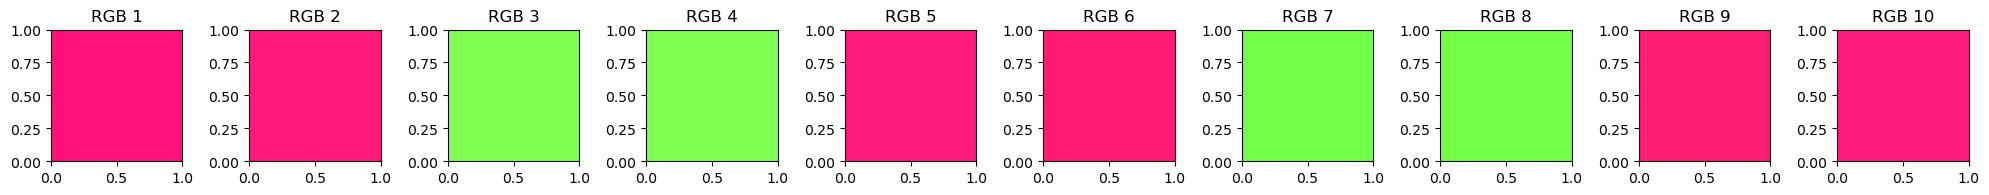

In [53]:
fig, axes = plt.subplots(1, len(rgbs), figsize=(len(rgbs)*2, 2))
for i, rgb in enumerate(rgbs):
    axes[i].add_patch(mpatches.Rectangle((0, 0), 1, 1, color=rgb))
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)
    axes[i].set_title(f'RGB {i+1}')
    axes[i].set_aspect('equal')
plt.tight_layout()
plt.show()


### Green fz reduced.

In [ ]:

# Median quaternions shape (not fz_reduced): (10, 4)
# Median Quaternion for green Pixel 1 at (0, 11): [ 0.26754582 -0.15486704 -0.75967145  0.5721316 ]
# Median Quaternion for green Pixel 2 at (0, 25): [ 0.72346    -0.31057626  0.11103532  0.60648143]
# Median Quaternion for green Pixel 3 at (0, 43): [ 0.87584054 -0.16261624 -0.2828368   0.35561562]
# Median Quaternion for green Pixel 4 at (0, 67): [ 0.8783544  -0.14681625 -0.28313166  0.3560554 ]
# Median Quaternion for green Pixel 5 at (1, 7): [ 0.26707643 -0.15652129 -0.7643729   0.56560206]
# Median Quaternion for green Pixel 6 at (1, 11): [ 0.26755545 -0.15491316 -0.75979406  0.5719518 ]
# Median Quaternion for green Pixel 7 at (1, 53): [ 0.4959523  -0.73542464  0.04689714  0.45932737]
# Median Quaternion for green Pixel 8 at (1, 71): [ 0.82095224 -0.41267872  0.13785821  0.36976814]
# Median Quaternion for green Pixel 9 at (1, 73): [0.81964606 0.14197719 0.41708672 0.36614355]
# Median Quaternion for green Pixel 10 at (2, 5): [ 0.7225367  -0.30460903  0.11765942  0.60935163]
# Median quaternions shape (fz_reduced): (10, 4)
# Median Quaternion for green Pixel 1 at (0, 11): [ 0.08002812 -0.29869005 -0.1322086   0.94175357]
# Median Quaternion for green Pixel 2 at (0, 25): [ 0.08344846 -0.2973736  -0.14052904  0.94066805]
# Median Quaternion for green Pixel 3 at (0, 43): [-0.3555534   0.28240055 -0.16261563  0.8760064 ]
# Median Quaternion for green Pixel 4 at (0, 67): [-0.35570097  0.28087437 -0.1486733   0.87891006]
# Median Quaternion for green Pixel 5 at (1, 7): [ 0.0774008  -0.29925138 -0.14056166  0.940585  ]
# Median Quaternion for green Pixel 6 at (1, 11): [ 0.07977104 -0.29855305 -0.13268514  0.94175196]
# Median Quaternion for green Pixel 7 at (1, 53): [-0.3579093   0.29124194 -0.16901739  0.8709263 ]
# Median Quaternion for green Pixel 8 at (1, 71): [-0.35757384  0.16611637  0.28887182  0.87240946]
# Median Quaternion for green Pixel 9 at (1, 73): [-0.35373956  0.28225905 -0.16275524  0.8767602 ]
# Median Quaternion for green Pixel 10 at (2, 5): [ 0.08004645 -0.298477   -0.13235442  0.94179934]

[[ 0.94175357  0.08002812 -0.29869005 -0.1322086 ]
 [ 0.94066805  0.08344846 -0.2973736  -0.14052904]
 [ 0.8760064  -0.3555534   0.28240055 -0.16261563]
 [ 0.87891006 -0.35570097  0.28087437 -0.1486733 ]
 [ 0.940585    0.0774008  -0.29925138 -0.14056166]
 [ 0.94175196  0.07977104 -0.29855305 -0.13268514]
 [ 0.8709263  -0.3579093   0.29124194 -0.16901739]
 [ 0.87240946 -0.35757384  0.16611637  0.28887182]
 [ 0.8767602  -0.35373956  0.28225905 -0.16275524]
 [ 0.94179934  0.08004645 -0.298477   -0.13235442]]
[[0.50591188 1.         0.32984443]
 [0.51067162 1.         0.33749116]
 [0.0590833  0.14407253 1.        ]
 [0.02680247 0.11147588 1.        ]
 [0.49059782 1.         0.28263757]
 [0.50588613 1.         0.32648828]
 [0.14027251 0.16801815 1.        ]
 [0.0813279  1.         0.28262526]
 [0.05120426 0.15109492 1.        ]
 [0.50708545 1.         0.32990565]]


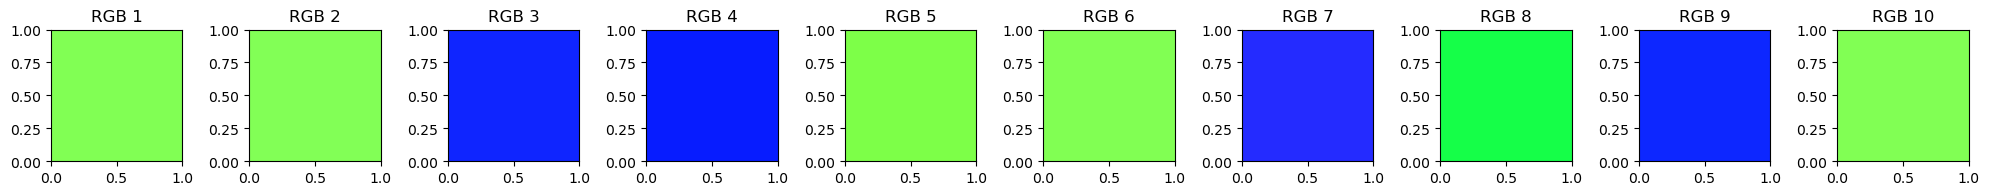

In [55]:
# get RGB colours for Qs
import os
#Example with three orientations
Qs = [	[ 0.08002812, -0.29869005, -0.1322086,   0.94175357],
[ 0.08344846, -0.2973736,  -0.14052904,  0.94066805],
[-0.3555534,   0.28240055, -0.16261563,  0.8760064 ],
[-0.35570097,  0.28087437, -0.1486733,   0.87891006],
[ 0.0774008,  -0.29925138, -0.14056166,  0.940585  ],
[ 0.07977104, -0.29855305, -0.13268514,  0.94175196],
[-0.3579093,   0.29124194, -0.16901739,  0.8709263 ],
[-0.35757384,  0.16611637,  0.28887182,  0.87240946],
[-0.35373956,  0.28225905, -0.16275524,  0.8767602 ],
[ 0.08004645, -0.298477,   -0.13235442,  0.94179934]
]
q = np.asarray(Qs)
# bring last quaternion dimension to the front (Scalar first)
# roll the last axis to the front (scalar first)
q = np.roll(q, shift=1, axis=-1)

print(q)  # prints quaternions in [s, x, y, z] order
rgbs = quaternion_to_ipf(q, axis="Z")  # ready for scatter
print(rgbs)  # prints RGB values in 0–1 range

# display RGB colours
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, len(rgbs), figsize=(len(rgbs)*2, 2))
for i, rgb in enumerate(rgbs):
    axes[i].add_patch(mpatches.Rectangle((0, 0), 1, 1, color=rgb))
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)
    axes[i].set_title(f'RGB {i+1}')
    axes[i].set_aspect('equal')
plt.tight_layout()
plt.show()



### Green fz not reduced

[[ 0.26754582 -0.15486704 -0.75967145  0.5721316 ]
 [ 0.72346    -0.31057626  0.11103532  0.60648143]
 [ 0.87584054 -0.16261624 -0.2828368   0.35561562]
 [ 0.8783544  -0.14681625 -0.28313166  0.3560554 ]
 [ 0.26707643 -0.15652129 -0.7643729   0.56560206]
 [ 0.26755545 -0.15491316 -0.75979406  0.5719518 ]
 [ 0.4959523  -0.73542464  0.04689714  0.45932737]
 [ 0.82095224 -0.41267872  0.13785821  0.36976814]
 [ 0.81964606  0.14197719  0.41708672  0.36614355]
 [ 0.7225367  -0.30460903  0.11765942  0.60935163]]
[[0.53928588 1.         0.82667875]
 [0.52779294 1.         0.87713524]
 [0.43557374 1.         0.38334194]
 [0.42631174 1.         0.25844265]
 [0.52067029 1.         0.88101747]
 [0.53865313 1.         0.82804792]
 [0.37854704 1.         0.38455965]
 [0.39771923 1.         0.36073487]
 [0.4171919  1.         0.33312065]
 [0.54053513 1.         0.82331019]]


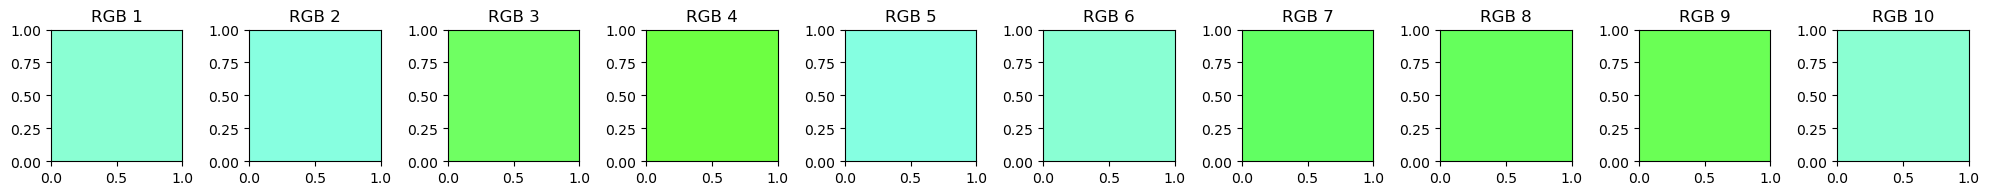

In [44]:
# get RGB colours for Qs
import os
#Example with three orientations
Qs = [[ 0.26754582, -0.15486704, -0.75967145,  0.5721316 ],
[ 0.72346,    -0.31057626,  0.11103532,  0.60648143],
[ 0.87584054, -0.16261624, -0.2828368,   0.35561562],
[ 0.8783544,  -0.14681625, -0.28313166,  0.3560554 ],
[ 0.26707643, -0.15652129, -0.7643729,   0.56560206],
[ 0.26755545, -0.15491316, -0.75979406,  0.5719518 ],
[ 0.4959523,  -0.73542464,  0.04689714,  0.45932737],
[ 0.82095224, -0.41267872,  0.13785821,  0.36976814],
[0.81964606, 0.14197719, 0.41708672, 0.36614355],
[ 0.7225367,  -0.30460903,  0.11765942,  0.60935163]
]
q = np.asarray(Qs)
# bring last quaternion dimension to the front (Scalar first)
# roll the last axis to the front (scalar first)
#q = np.roll(q, shift=1, axis=-1)

print(q)  # prints quaternions in [s, x, y, z] order
rgbs = quaternion_to_ipf(q, axis="Z")  # ready for scatter
print(rgbs)  # prints RGB values in 0–1 range

# display RGB colours
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, len(rgbs), figsize=(len(rgbs)*2, 2))
for i, rgb in enumerate(rgbs):
    axes[i].add_patch(mpatches.Rectangle((0, 0), 1, 1, color=rgb))
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)
    axes[i].set_title(f'RGB {i+1}')
    axes[i].set_aspect('equal')
plt.tight_layout()
plt.show()

